In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import sys
import os
sys.path.append(os.path.abspath(".."))

import utils.plot_utils as pu

In [2]:
# Adaline Model 
# hyperparameters - eta, n_iter
# X - (examples, features)
# y - (examples,)
# w - (features,)

class Adaline:
    # ADaptive LInear NEuron classifier
    def __init__(self, eta=0.01, n_iter = 50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self, X, y):
        self.b_ = 0.0
        self.loss_ = []

        rgen = np.random.default_rng(self.random_state)
        self.w_ = rgen.normal(loc=0, scale=0.3, size=X.shape[1])

        for i in range(self.n_iter):
            z = self.activation(self.net_input(X))
            delta = (y-z) 
            self.w_ += (self.eta * 2 * X.T.dot(delta)/y.size)
            self.b_ += (self.eta * 2 * np.mean(delta))

            mse =  (delta**2).mean()
            self.loss_.append(mse)


    def net_input(self, X):
        # calculate net input
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        # calculate linear activation
        # In this case an identity function
        return X

    def predict(self, X):
        # predict class label
        return np.where(self.activation(self.net_input(X))>=0.5, 1, 0)
    

In [3]:
# Importing and formatting the data
path = '../data/iris.data'
data = pd.read_csv(path, header=None, encoding='utf-8')
print(data.head())

# setting up input and output
X = data.iloc[0:100, [0,2]].to_numpy()
# print(X[:5])

y = data.iloc[0:100, 4]
y = np.where(y=='Iris-setosa', 0, 1)
# print(y[:5])
# print(y[95:])

# feature scaling using standardization method
X_std = np.copy(X)
X_std[:,0] = (X[:,0]-X[:,0].mean())/X[:,0].std()
X_std[:,1] = (X[:,1]-X[:,1].mean())/X[:,1].std()

     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa


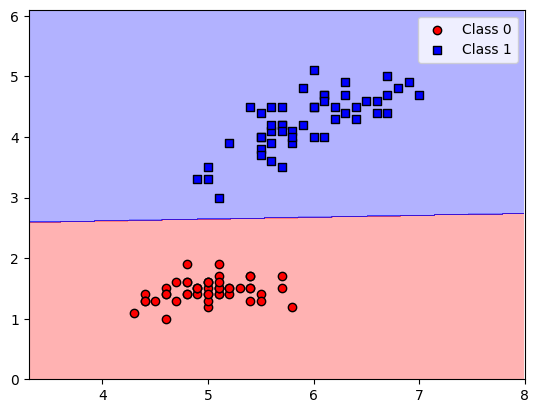

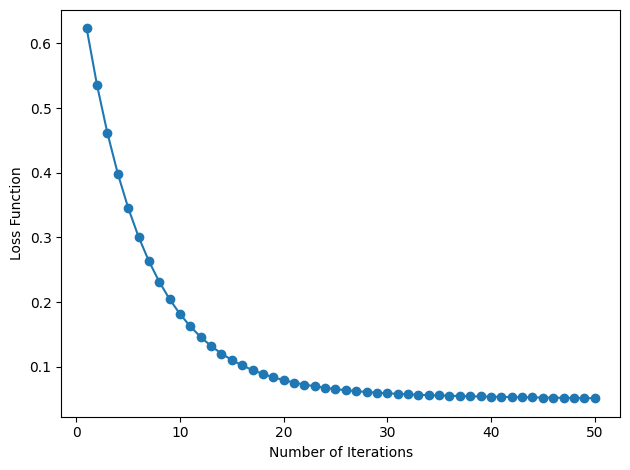

In [4]:
# Model fitting on original data
ada1 = Adaline(eta=0.001, n_iter=50, random_state=1)
ada1.fit(X, y)

pu.plot_decision_regions(X=X, y=y, model=ada1)
plt.show()

pu.plot_loss(ada1.n_iter, ada1.loss_)
plt.show()


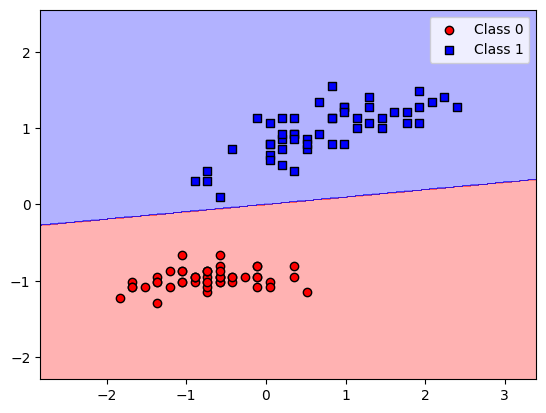

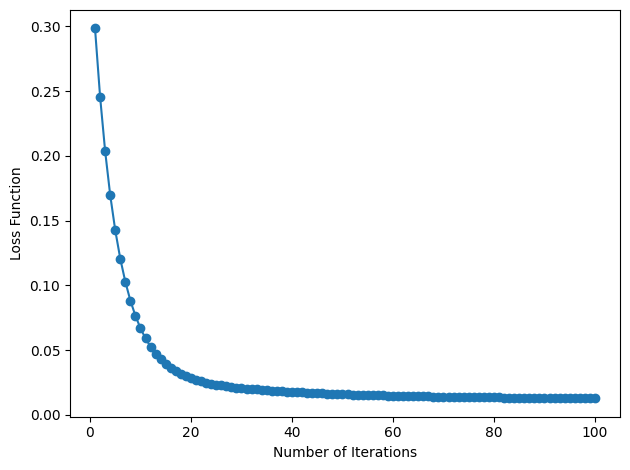

In [5]:
# Model fitting on scaled feature data
ada2 = Adaline(eta=0.05, n_iter=100, random_state=1)
ada2.fit(X_std, y)

pu.plot_decision_regions(X=X_std, y=y, model=ada2)
plt.show()

pu.plot_loss(ada2.n_iter, ada2.loss_)
plt.show()